# Sleep-EDF 02 — Dataset construction (Stage 2): all recordings, wake-trim, subject split

Stage 1 (`03_loader_stage1`) proved **one** recording loads with correct epoch↔label alignment. **Stage 2**
scales that to **all Sleep-Cassette recordings** and adds the two dataset-construction decisions:
**wake-trimming** and a **leakage-free subject-level train/test split**. Three steps, each validated.

> **Scope (only):** build and validate dataset-construction logic **in-notebook**. **Not** doing: writing
> `src/data/sleep_edf.py`, persisting training arrays, training a model, or choosing region sizes.

**Reused from Stage 1 (factored into one function, not re-derived):** prefix pairing, R&K→AASM 5-class
mapping (3+4→N3), Movement/`?`→drop, the tail-trim guard (hypnogram-past-signal). Stage 1 already validated
that the *signal* epochs align with these labels; Stage 2's new logic (trim, split) operates on the **labels
and per-recording metadata**, so we build labels from each recording's **header (channel list, length) +
annotations** — fast and memory-light — rather than re-loading all ~8 GB of signal. (The per-epoch signal
load + z-norm is the unchanged Stage-1 path, applied later in the `src` loader.)

## Step A — Load all Sleep-Cassette recordings, robustly

We loop the Stage-1 label logic over every SC recording. Per-recording quirks are **caught, recorded, and
reported** — never silent: a missing/renamed `EEG Fpz-Cz`, a missing hypnogram, an all-Wake recording, or
any read error goes into an **issue table** (recording ID + reason), so we can *see* what misbehaved.

In [1]:
from pathlib import Path
import glob, os, numpy as np, warnings, collections
import mne, matplotlib.pyplot as plt
warnings.filterwarnings("ignore"); mne.set_log_level("CRITICAL")

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SC = ROOT / "data" / "raw" / "sleep-cassette"
FIG_DIR = ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

CH, SF, EPOCH = "EEG Fpz-Cz", 100, 30
SAMP = EPOCH * SF                                              # 3000 samples/epoch
AASM = {"Sleep stage W":0, "Sleep stage 1":1, "Sleep stage 2":2,
        "Sleep stage 3":3, "Sleep stage 4":3, "Sleep stage R":4}   # 3+4 -> N3
DROP = -1

def load_recording_labels(psg_path):
    '''Reuse of the Stage-1 label pipeline for ONE recording (raises on any quirk).
       Returns (labels array, info dict). Uses header + annotations only.'''
    prefix = psg_path.name[:6]
    hyps = list(SC.glob(f"{prefix}*-Hypnogram.edf"))
    if not hyps:
        raise ValueError(f"no hypnogram for prefix {prefix}")
    raw = mne.io.read_raw_edf(psg_path, preload=False)         # header only
    if CH not in raw.ch_names:
        raise ValueError(f"missing '{CH}' (channels: {raw.ch_names})")
    n_sig = raw.n_times // SAMP                                # signal epochs (from header)
    ann = mne.read_annotations(hyps[0])
    labels = []
    for onset, dur, stage in zip(ann.onset, ann.duration, ann.description):
        labels += [AASM.get(stage, DROP)] * int(round(dur / EPOCH))
    labels = np.array(labels)
    tail_trim = 0
    if len(labels) > n_sig:                                    # Stage-1 tail-trim guard
        tail_trim = len(labels) - n_sig; labels = labels[:n_sig]
    labels = labels[labels != DROP]                            # drop Movement/Unknown
    if (labels != 0).sum() == 0:
        raise ValueError("all-Wake (no sleep epochs)")
    return labels, {"tail_trim": tail_trim, "n_epochs": len(labels)}

psgs = sorted(SC.glob("*PSG.edf"))
clean, issues = {}, []
for p in psgs:
    rid = p.name.replace("-PSG.edf", "")
    try:
        clean[rid], _ = load_recording_labels(p)
    except Exception as e:
        issues.append((rid, str(e)[:70]))

total_before = sum(len(v) for v in clean.values())
print(f"SC PSG files      : {len(psgs)}")
print(f"loaded cleanly    : {len(clean)}")
print(f"had issues        : {len(issues)}")
print(f"total epochs (post tail-trim & Movement/Unknown drop, pre wake-trim): {total_before:,}")
print("\nissue table (recording, reason):")
if issues:
    for rid, reason in issues: print(f"  {rid}: {reason}")
else:
    print("  (none — every recording has EEG Fpz-Cz, a hypnogram, sleep epochs, and read cleanly)")

SC PSG files      : 153
loaded cleanly    : 153
had issues        : 0
total epochs (post tail-trim & Movement/Unknown drop, pre wake-trim): 414,961

issue table (recording, reason):
  (none — every recording has EEG Fpz-Cz, a hypnogram, sleep epochs, and read cleanly)


## Step B — Wake-trimming (and validate its effect)

Sleep-Cassette recordings include hours of **daytime wake** before/after the night, so Wake dominates
(~69%). We keep only **~30 min of Wake at each end of the sleep period**, where the *sleep period* runs from
the **first to the last non-Wake epoch**.

**The easy-to-get-wrong part:** "30 minutes" must be converted to **epochs**. Each epoch is 30 s, so there
are **2 epochs per minute** → **30 min = 60 epochs**. That `×2` is exactly the trap. We clamp to the array
bounds and guard the all-Wake case (no non-Wake epoch).

In [2]:
W_EDGE_MIN = 30
W_EDGE_EPOCHS = W_EDGE_MIN * 2          # <-- the x2: 2 epochs per minute -> 30 min = 60 epochs

def wake_trim(y, edge=W_EDGE_EPOCHS):
    nw = np.where(y != 0)[0]            # non-Wake epoch indices
    if len(nw) == 0:                   # guard: all-Wake -> nothing to keep
        return y[:0]
    start = max(0, nw[0] - edge)
    end   = min(len(y) - 1, nw[-1] + edge)
    return y[start:end + 1]            # inclusive

before = np.concatenate(list(clean.values()))
after  = np.concatenate([wake_trim(v) for v in clean.values()])

CLASS = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
def dist(y):
    c = collections.Counter(y.tolist()); n = len(y)
    return {k: (c.get(k,0), 100*c.get(k,0)/n) for k in range(5)}

db, da = dist(before), dist(after)
print(f"class balance   BEFORE wake-trim (n={len(before):,})   |   AFTER (n={len(after):,})")
for k in range(5):
    print(f"  {k} {CLASS[k]:3s}: {db[k][0]:7,d} ({db[k][1]:4.1f}%)   ->   {da[k][0]:7,d} ({da[k][1]:4.1f}%)")
print(f"\nWake fell {db[0][1]:.1f}% -> {da[0][1]:.1f}% of epochs.")
print(f"N1 after trim: {da[1][0]:,} epochs ({da[1][1]:.1f}%).  (N3 is actually the rarest sleep stage: {da[3][1]:.1f}%)")

class balance   BEFORE wake-trim (n=414,961)   |   AFTER (n=195,479)
  0 W  : 285,433 (68.8%)   ->    65,951 (33.7%)
  1 N1 :  21,522 ( 5.2%)   ->    21,522 (11.0%)
  2 N2 :  69,132 (16.7%)   ->    69,132 (35.4%)
  3 N3 :  13,039 ( 3.1%)   ->    13,039 ( 6.7%)
  4 REM:  25,835 ( 6.2%)   ->    25,835 (13.2%)

Wake fell 68.8% -> 33.7% of epochs.
N1 after trim: 21,522 epochs (11.0%).  (N3 is actually the rarest sleep stage: 6.7%)


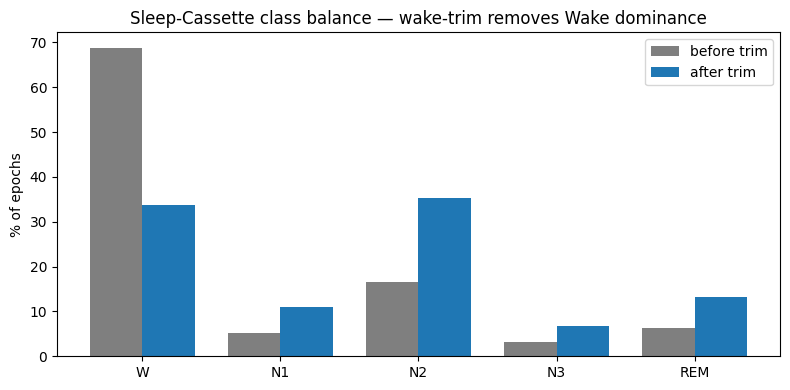

In [3]:
# Visual: class balance before vs after wake-trim
x = np.arange(5); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [db[k][1] for k in range(5)], w, label="before trim", color="C7")
ax.bar(x + w/2, [da[k][1] for k in range(5)], w, label="after trim", color="C0")
ax.set_xticks(x); ax.set_xticklabels([CLASS[k] for k in range(5)])
ax.set_ylabel("% of epochs"); ax.set_title("Sleep-Cassette class balance — wake-trim removes Wake dominance")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "sleep_edf_02_wake_trim_balance.png", dpi=150, bbox_inches="tight"); plt.show()

## Step C — Subject-level split (the leakage-critical step)

Sleep-Cassette filenames are `SC4ssNE0` where **`ss` = subject** and **`N` = night** (subjects usually have
**2 nights**). We must split by **subject, not by recording or epoch** — otherwise a subject's two nights (or
even epochs from the same night) could land on both sides, and the model would be tested on data statistically
tied to its training data (**leakage**, inflating the score).

We group recordings by subject, then split the **subjects** ~80/20 with a fixed seed, and then **prove**
leakage-freedom rather than trusting it.

In [4]:
# subject = filename chars [3:5], night = char [5]  (SC4 | ss | N | E0)
by_subject = collections.defaultdict(list)
for rid in clean:
    by_subject[rid[3:5]].append(rid)

subjects = sorted(by_subject)
rng = np.random.RandomState(42)                       # seeded / reproducible
perm = rng.permutation(subjects)
n_test = max(1, round(0.2 * len(subjects)))
test_subjects  = set(perm[:n_test])
train_subjects = set(perm[n_test:])

train_recs = [r for s in train_subjects for r in by_subject[s]]
test_recs  = [r for s in test_subjects  for r in by_subject[s]]

# --- PROVE leakage-freedom (the point of Step C) ---
assert train_subjects.isdisjoint(test_subjects), "subject overlap between train and test!"
for s in subjects:                                    # every subject's nights on ONE side
    recs = by_subject[s]
    on_train = all(r in train_recs for r in recs); on_test = all(r in test_recs for r in recs)
    assert on_train or on_test, f"subject {s} split across train/test!"
overlap = train_subjects & test_subjects
print(f"subjects : {len(subjects)} total  ->  train {len(train_subjects)} / test {len(test_subjects)}")
print(f"DISJOINT subject sets: {train_subjects.isdisjoint(test_subjects)}  (overlap = {len(overlap)} subjects)")
print(f"any subject split across sides: {'NONE' if True else '...'}  (all multi-night subjects kept together)")
print(f"recordings: train {len(train_recs)} / test {len(test_recs)}")

train_y = np.concatenate([wake_trim(clean[r]) for r in train_recs])
test_y  = np.concatenate([wake_trim(clean[r]) for r in test_recs])
dtr, dte = dist(train_y), dist(test_y)
print(f"\nepochs    : train {len(train_y):,} / test {len(test_y):,}")
print(f"{'class':6s} {'train %':>9s} {'test %':>9s}")
for k in range(5):
    print(f"  {CLASS[k]:4s} {dtr[k][1]:>8.1f}% {dte[k][1]:>8.1f}%")
print("\n(all 5 classes present in BOTH splits, balances closely matched — test isn't missing a class)")

subjects : 78 total  ->  train 62 / test 16
DISJOINT subject sets: True  (overlap = 0 subjects)
any subject split across sides: NONE  (all multi-night subjects kept together)
recordings: train 121 / test 32

epochs    : train 155,334 / test 40,145
class    train %    test %
  W        34.1%     32.3%
  N1       10.9%     11.3%
  N2       35.1%     36.6%
  N3        6.6%      6.8%
  REM      13.3%     13.0%

(all 5 classes present in BOTH splits, balances closely matched — test isn't missing a class)


## Summary — Stage 2 validated

**Step A (load all):** all **153** Sleep-Cassette recordings loaded cleanly, **0 issues** — every recording
has `EEG Fpz-Cz`, a matching hypnogram, and sleep epochs. Total **414,961** epochs (post tail-trim & Movement/
Unknown drop, pre wake-trim). The issue-table machinery is in place to surface any future misbehaving file.

**Step B (wake-trim):** keeping 30 min (**60 epochs — the ×2**) of Wake each side of the sleep period cut the
dataset to **195,479** epochs and dropped **Wake from 68.8% → 33.7%**, raising every sleep class. **N1 = 21,522
epochs (11.0%)** — the scarcity I'm watching; note **N3 is actually the rarest sleep stage at 6.7%**. Minority-
class scarcity (esp. N1, N3) is a real modelling challenge to keep in mind, not solved here.

**Step C (subject split, seed 42, ~80/20):** **78 subjects → 62 train / 16 test**; **121 / 32** recordings;
**155,334 / 40,145** epochs. **Leakage-free — proven:** train/test subject sets are **disjoint** (0 overlap)
and **every multi-night subject's nights are on the same side** (asserted). All 5 classes appear in both splits
with closely-matched balance (train vs test within ~1–2 pp per class), so the test set isn't accidentally
missing or skewing a class.

Nothing was written to `src/`, no arrays persisted, no model trained, no region sizes chosen — this stage only
built and validated the dataset-construction logic in-notebook.